# Jev vs Gemini from BigQuery

## tl;dr

- Jev: 85.5% accuracy, $0.00788 theoretical model cost for 200 rows.
- Gemini 2.5 Flash-Lite on the same Vercel AI Gateway path: 86.0%, $0.01554.
- Jev p50 latency is 545ms versus 1,950ms for Flash-Lite, about 3.6× faster.
- Gemini 3.1 Pro Preview: 88.5%, $0.55055.
- A broad Pro rerank of similar labels did not improve cost-effectiveness.

This executed notebook is the auditable companion to the article. It contains aggregate results only, not Stack Overflow question text or credentials.

## Context & Methods

### Key assumptions

- Source table: [`bigquery-public-data.stackoverflow.posts_questions`](https://console.cloud.google.com/bigquery?p=bigquery-public-data&d=stackoverflow&t=posts_questions&page=table).
- The top-20, single-tag task follows [Google Cloud's Keras example](https://cloud.google.com/blog/products/gcp/intro-to-text-classification-with-keras-automatically-tagging-stack-overflow-posts).
- The evaluation set has 20 tags × 10 questions, selected deterministically.
- Primary runs use the same route: BigQuery → Remote Function → Cloud Run → Vercel AI Gateway.
- Models receive the same question text, instruction, candidate names, and candidate descriptions. API-specific structured-output wrappers necessarily differ.
- Cost is observed tokens × public model price. Infrastructure, failed calls, retries, and credits are excluded.

## Data

Question text is intentionally not redistributed. `sql/01_prepare_stackoverflow.sql` rebuilds the evaluation set from the public BigQuery table. The notebook analyzes the committed aggregate result file.

In [1]:
from pathlib import Path
import pandas as pd

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
summary_path = repo_root / "results" / "summary.csv"
results = pd.read_csv(summary_path)
performance = pd.read_csv(repo_root / "results" / "performance.csv")
results[["method", "accuracy", "correct", "total", "theoretical_model_cost_usd"]].tail(10)

,method,accuracy,correct,total,theoretical_model_cost_usd
5,Jev one-shot per label,0.860,172.0,200.0,0.009674
6,Jev ambiguous rerank,0.850,170.0,200.0,0.011565
7,BQML Random Forest,NaN,NaN,NaN,NaN
8,Jev + Gemini 3.8 Flash rerank,0.865,173.0,200.0,0.066046
9,Gemini 2.5 Flash-Lite + Gemini 3.8 Flash rerank,0.855,171.0,200.0,0.075124
10,Gemini 3.8 Flash full,0.870,174.0,200.0,0.158212
11,Jev + Gemini 3.1 Pro rerank,0.860,172.0,200.0,0.275126
12,Gemini 2.5 Flash-Lite + Gemini 3.1 Pro rerank,0.850,170.0,200.0,0.278731
13,Gemini 3.1 Pro full,0.885,177.0,200.0,0.550554
14,Gemini 2.5 Flash-Lite via Gateway + Gemini 3.1...,0.845,169.0,200.0,0.276779


## Results

The primary table below keeps only the gateway-equalized baseline models, latest Pro, and the two Pro rerank pipelines.

In [2]:
primary_methods = [
    "Jev baseline",
    "Gemini 2.5 Flash-Lite via Vercel AI Gateway",
    "Jev + Gemini 3.1 Pro rerank",
    "Gemini 2.5 Flash-Lite via Gateway + Gemini 3.1 Pro rerank",
    "Gemini 3.1 Pro full",
]

primary = (
    results[results["method"].isin(primary_methods)]
    .assign(
        accuracy_pct=lambda frame: frame["accuracy"] * 100,
        cost_per_1000_usd=lambda frame: frame["theoretical_model_cost_usd"] * 5,
    )
    [["method", "accuracy_pct", "correct", "total", "theoretical_model_cost_usd", "cost_per_1000_usd"]]
    .sort_values("theoretical_model_cost_usd")
)
primary

/Users/user/Documents/Codex/2026-09-20/new-chat/work/compare-jev-bigquery-ai-functions/.venv/lib/python3.14/site-packages/pandas/core/frame.py:5246: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data[k] = com.apply_if_callable(v, data)
/User

,method,accuracy_pct,correct,total,theoretical_model_cost_usd,cost_per_1000_usd
0,Jev baseline,85.5,171.0,200.0,0.007882,0.039408
2,Gemini 2.5 Flash-Lite via Vercel AI Gateway,86.0,172.0,200.0,0.015539,0.077696
11,Jev + Gemini 3.1 Pro rerank,86.0,172.0,200.0,0.275126,1.375628
14,Gemini 2.5 Flash-Lite via Gateway + Gemini 3.1...,84.5,169.0,200.0,0.276779,1.383895
13,Gemini 3.1 Pro full,88.5,177.0,200.0,0.550554,2.752770


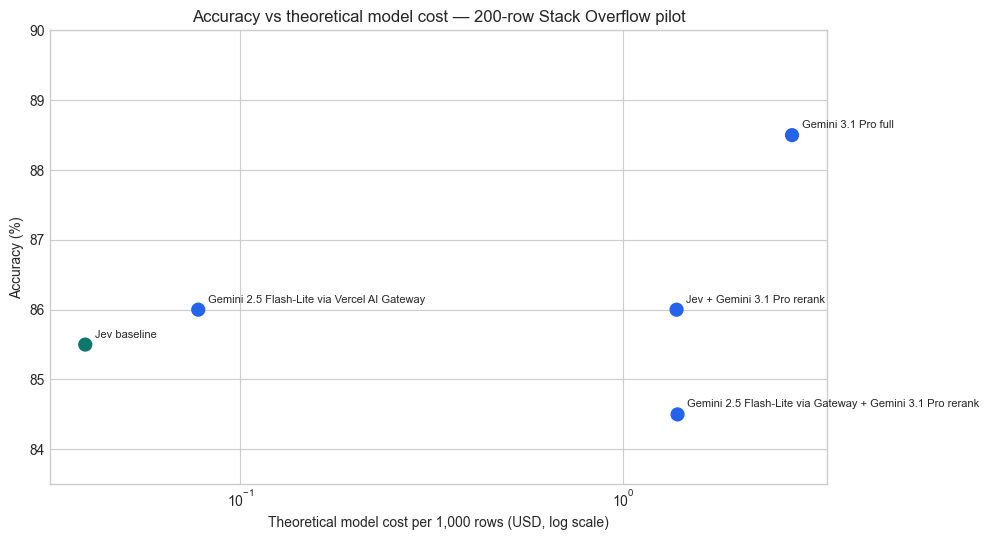

In [3]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
colors = ["#0F766E" if "Jev baseline" == name else "#2563EB" for name in primary["method"]]
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(primary["cost_per_1000_usd"], primary["accuracy_pct"], s=85, c=colors)
for row in primary.itertuples():
    ax.annotate(
        row.method,
        (row.cost_per_1000_usd, row.accuracy_pct),
        xytext=(7, 5),
        textcoords="offset points",
        fontsize=8,
    )
ax.set_xscale("log")
ax.set_title("Accuracy vs theoretical model cost — 200-row Stack Overflow pilot")
ax.set_xlabel("Theoretical model cost per 1,000 rows (USD, log scale)")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(83.5, 90)
fig.tight_layout()
plt.show()

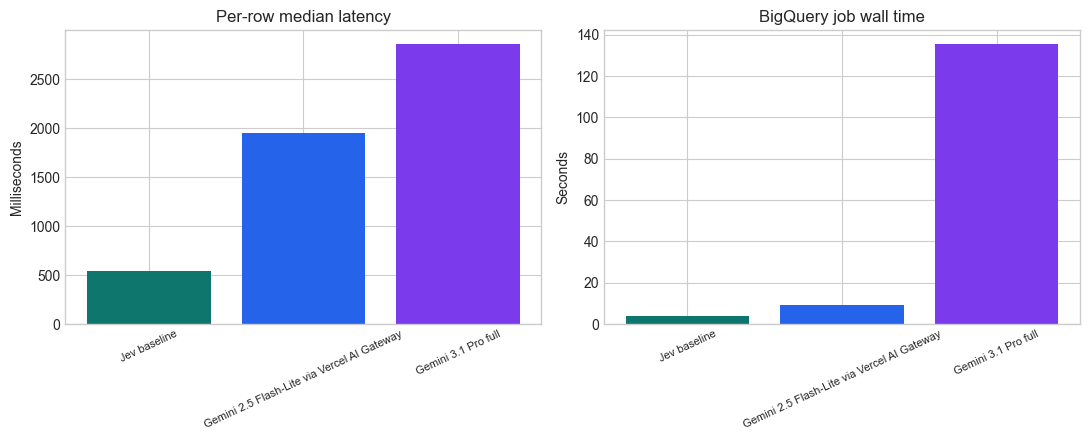

In [4]:
speed = performance[performance["method"].isin([
    "Jev baseline",
    "Gemini 2.5 Flash-Lite via Vercel AI Gateway",
    "Gemini 3.1 Pro full",
])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(speed["method"], speed["p50_latency_ms"], color=["#0F766E", "#2563EB", "#7C3AED"])
axes[0].set_title("Per-row median latency")
axes[0].set_ylabel("Milliseconds")
axes[0].tick_params(axis="x", rotation=25, labelsize=8)

axes[1].bar(speed["method"], speed["bigquery_job_seconds"], color=["#0F766E", "#2563EB", "#7C3AED"])
axes[1].set_title("BigQuery job wall time")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=25, labelsize=8)
fig.tight_layout()
plt.show()

### Interpretation

Jev and Gemini 2.5 Flash-Lite differ by one correct answer in 200 rows, while Jev's theoretical model cost is about half and its p50 latency is about 3.6× faster. Gemini 3.1 Pro is the most accurate, but its cost is about 70× Jev's for this prompt. The broad rerank rule sends 144–147 rows to Pro and sometimes replaces correct first-stage answers with wrong ones.

## Checks

In [5]:
assert set(primary_methods) == set(primary["method"])
assert len(primary) == 5
assert (primary["total"] == 200).all()
assert primary["accuracy_pct"].between(0, 100).all()
assert primary["theoretical_model_cost_usd"].gt(0).all()

jev = primary.loc[primary["method"] == "Jev baseline"].iloc[0]
flash_lite = primary.loc[primary["method"] == "Gemini 2.5 Flash-Lite via Vercel AI Gateway"].iloc[0]
pro = primary.loc[primary["method"] == "Gemini 3.1 Pro full"].iloc[0]

checks = {
    "Jev correct": int(jev["correct"]),
    "Gateway Flash-Lite correct": int(flash_lite["correct"]),
    "Pro correct": int(pro["correct"]),
    "Jev cost reduction vs Gateway Flash-Lite": 1 - jev["theoretical_model_cost_usd"] / flash_lite["theoretical_model_cost_usd"],
    "Pro / Jev cost multiple": pro["theoretical_model_cost_usd"] / jev["theoretical_model_cost_usd"],
}
checks

{'Jev correct': 171,
 'Gateway Flash-Lite correct': 172,
 'Pro correct': 177,
 'Jev cost reduction vs Gateway Flash-Lite': np.float64(0.4927865835215681),
 'Pro / Jev cost multiple': np.float64(69.85272100730305)}

## Takeaways

For this closed 20-label task, Jev nearly matches Gemini 2.5 Flash-Lite at materially lower model cost. Pro improves the result by only a few questions and a broad two-stage rule is not selective enough. The practical lesson is to test the full execution path—including retries and per-row prompt repetition—before scaling a SQL proof of concept to hundreds of thousands of rows.

This is a 200-row pilot. Stack Overflow tags are observed user labels, not objective ground truth, and model prices can change.